# 04 — Imputation & Monte Carlo Simulation

This notebook runs the full imputation pipeline:
1. Outcome model (OLS log-normal imputer)
2. Propensity estimation (LM + GAM)
3. Monte Carlo simulation with exponential tilting
4. Diagnostics and plots

All variant-specific settings (instrument, sector granularity, number of MC draws)
are controlled by the **`SPEC`** dictionary in the first code cell.
Change it to run baseline vs. robustness checks — the rest of the notebook is identical.

## Configuration

Edit **only this cell** to switch between specifications.

| Key | Description |
|-----|-------------|
| `name` | Short tag used in all output filenames |
| `x_columns` | Columns for the outcome model (imputer) |
| `sector_col` | `"gind"` (GICS industry) or `"gsector"` (GICS sector) |
| `iv_term` | Name of the log-transformed IV column created below |
| `n_mc` | Number of Monte Carlo draws |
| `want_balanced` | Balance the propensity sample (LM only) |
| `filter_min_obs` | If `True`, drop industries with < 5 disclosers or < 5 non-disclosers |
| `run_gam` | If `True`, also estimate GAM propensity (slower); set `False` for LM-only runs |
| `lm_base_x` | Custom base regressors for LM propensity (default `None` = automatic) |
| `interaction_cutoff` | Year cutoff for emissions x post interaction (default `None` = no interaction) |
| `interaction_col` | Name of the interaction column (required if `interaction_cutoff` is set) |
| `run_yearly_gamma` | If `True`, fit year-by-year logit propensities and plot γ_t with 95% CIs |

### Output files produced

All outputs are tagged with the `name` field so different specs never overwrite each other.

| Output | Path |
|--------|------|
| Outcome model table | `data/outputs/tables/OutcomeModel_{name}.tex` |
| LM response boxplot | `data/outputs/figures/response_box_plot_lm_{name}.pdf` |
| GAM response panel | `data/outputs/figures/response_box_plot_gam_{name}.pdf` (only if `run_gam=True`) |
| Gamma pre/post plot | `data/outputs/figures/gamma_post_{name}.pdf` (only if `interaction_cutoff` is set) |
| Gamma by year plot | `data/outputs/figures/gamma_by_year_{name}.pdf` (only if `run_yearly_gamma=True`) |
| MC-averaged LM panel | `data/processed/df_lm_avg_{name}.parquet` |
| MC-averaged GAM panel | `data/processed/df_gam_avg_{name}.parquet` (only if `run_gam=True`) |

In [1]:
# ============================================================
# SPEC — change this dict to run a different specification
# ============================================================

SPEC = dict(
    name              = "baseline_wti_gind_500mc",
    x_columns         = ["at", "year", "gind", "z_wti"],
    sector_col        = "gsector",
    iv_term           = "z_wti",
    n_mc              = 500,
    want_balanced     = True,
    filter_min_obs    = False, #For gindustry specification, to have enough obs per sector for mc simulations in GAM
    run_gam           = True,
    lm_base_x         = None,
    interaction_cutoff = None,
    interaction_col   = None,
    run_yearly_gamma  = False, #For yearly gamma plot
)


# --- Robustness alternatives (uncomment one to run) ----------

# SPEC = dict(
#     name              = "wti",
#     x_columns         = ["at", "year", "gsector", "log_wti"],
#     sector_col        = "gsector",
#     iv_term           = "log_wti",
#     n_mc              = 300,
#     want_balanced     = False,
#     filter_min_obs    = False,
#     run_gam           = True,
#     lm_base_x         = None,
#     interaction_cutoff = None,
#     interaction_col   = None,
#     run_yearly_gamma  = False,
# )

# SPEC = dict(
#     name              = "500mc",
#     x_columns         = ["at", "year", "gsector", "gdp"],
#     sector_col        = "gsector",
#     iv_term           = "gdp",
#     n_mc              = 500,
#     want_balanced     = False,
#     filter_min_obs    = False,
#     run_gam           = False,
#     lm_base_x         = None,
#     interaction_cutoff = None,
#     interaction_col   = None,
#     run_yearly_gamma  = False,
# )

# SPEC = dict(
#     name              = "tilt_test",
#     x_columns         = ["at", "year", "gind", "log_gdp"],
#     sector_col        = "gind",
#     iv_term           = "gdp",
#     n_mc              = 300,
#     want_balanced     = True,
#     filter_min_obs    = True,
#     run_gam           = False,
#     lm_base_x         = ["at", "sc1_disclosed_complete", "emissions_x_post_sec"],
#     interaction_cutoff = 2022,
#     interaction_col   = "emissions_x_post_sec",
#     run_yearly_gamma  = False,
# )

TAG = SPEC["name"]
RUN_GAM = SPEC["run_gam"]
HAS_INTERACTION = SPEC["interaction_cutoff"] is not None
RUN_YEARLY_GAMMA = SPEC.get("run_yearly_gamma", False)
print(f"Running specification: {TAG} (GAM: {'yes' if RUN_GAM else 'no'}, "
      f"interaction: {'yes' if HAS_INTERACTION else 'no'}, "
      f"yearly gamma: {'yes' if RUN_YEARLY_GAMMA else 'no'})")

Running specification: baseline_wti_gind_500mc (GAM: yes, interaction: no, yearly gamma: no)


## Setup & data loading

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

DIR_TABLES  = Path("../data/outputs/tables");  DIR_TABLES.mkdir(parents=True, exist_ok=True)
DIR_FIGURES = Path("../data/outputs/figures"); DIR_FIGURES.mkdir(parents=True, exist_ok=True)
DIR_PROC    = Path("../data/processed");       DIR_PROC.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.5,
    'figure.dpi':        150,
    'savefig.dpi':       300,
})

C_BLUE   = '#2166ac'
C_ORANGE = '#f4a020'
C_GREEN  = '#2ca02c'

In [3]:
read_path = DIR_PROC / "all_empiricals.parquet"

df = pd.read_parquet(
    read_path,
    engine="pyarrow"
)

# Optional: filter industries with too few observations in each class
if SPEC["filter_min_obs"]:
    col = 'gind'
    counts = df.groupby(col)["co2_bool"].agg(["sum", "count"])
    keep = counts[(counts["sum"] >= 10) & (counts["count"] - counts["sum"] >= 10)].index
    df = df[df[col].isin(keep)]
    print(f"Filtered to {df[col].nunique()} {col} groups ({len(df):,} obs)")

# Macro series, kept as TRUE log levels -- do not overwrite these.
df["log_wti"] = np.log(df["wti_crude"])
df["log_gdp"] = np.log(df["gdp"])

In [4]:
# ---- Shift-share instrument: z_wti = log(WTI_t) x predetermined firm exposure_i ----
df = df.sort_values(['gvkey', 'year'])
df['ppe_at'] = df['ppegt'] / df['at']

# Predetermined exposure: each firm's earliest available PP&E intensity (first up to 5 obs),
# held fixed thereafter, so only the aggregate shock varies over time.
expo = df.groupby('gvkey')['ppe_at'].apply(lambda s: s.dropna().head(5).mean())
df['exposure'] = df['gvkey'].map(expo)

# NOTE: ~12% of rows have no reported gross PP&E -- overwhelmingly Financials and
# Real Estate. Option A (current) drops them, which removes those sectors from the
# sample entirely. Option B keeps the full universe by assigning them their
# sector-median exposure (they genuinely have ~no physical oil exposure).
df = df.dropna(subset=['exposure'])                                                    # Option A
# df['exposure'] = df['exposure'].fillna(df.groupby('gsector')['exposure'].transform('median'))  # Option B
# df['exposure'] = df['exposure'].fillna(df['exposure'].median())                                # Option B

df.reset_index(drop=True, inplace=True)

lo, hi = df['exposure'].quantile([0.01, 0.99])
print(f"exposure range before clip: [{df['exposure'].min():.2f}, {df['exposure'].max():.2f}]; clip to [{lo:.3f},{hi:.3f}]")
df['exposure'] = df['exposure'].clip(lo, hi)
df['exposure'] = (df['exposure'] - df['exposure'].mean()) / df['exposure'].std()

# The instrument. log_wti stays the plain log oil price.
df['z_wti'] = df['exposure'] * df['log_wti']
print(f"z_wti built: {df['z_wti'].notna().sum():,} non-null of {len(df):,} rows")


exposure range before clip: [0.00, 7.97]; clip to [0.000,1.927]
z_wti built: 51,355 non-null of 51,355 rows


## Outcome model (OLS log-normal imputer)

In [5]:
from corporate_omissions.models.ols_lognormal_imputer import OLSLogNormalImputer

imp = OLSLogNormalImputer()

out = imp.fit_simulate(
    df,
    x_columns=SPEC["x_columns"],
    n_draws=10,
    draws_wide=True,
    quantiles=(0.05, 0.50, 0.95),
    print_summary=True,
)

df_full = out["df_full"]

                            OLS Regression Results                            
Dep. Variable:                 _log_y   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     373.6
Date:                Thu, 16 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:00:26   Log-Likelihood:                -11278.
No. Observations:                6698   AIC:                         2.271e+04
Df Residuals:                    6622   BIC:                         2.323e+04
Df Model:                          75                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.8807      0.183     21.193

In [6]:
from corporate_omissions.visualization.outcome_model_table import (
    build_outcome_model_table_from_imputer, write_text
)

model = out["model"]

latex = build_outcome_model_table_from_imputer(
    model,
    caption=(
        r"\textbf{Outcome model results.} Linear regression of log Scope~1 "
        r"emissions on firm characteristics, macroeconomic conditions, sector "
        r"indicators, and year fixed effects. Robust standard errors in "
        r"parentheses. Significance levels: $^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.1$."
    ),
    label=f"tab:OutcomeModel_{TAG}",
    baseline_sector="Communication",
    baseline_year=2012,
    gdp_term="z_wti",
    assets_term="log_at",
)

write_text(DIR_TABLES / f"OutcomeModel_{TAG}.tex", latex)
print(f"Saved: {DIR_TABLES / f'OutcomeModel_{TAG}.tex'}")

Saved: ../data/outputs/tables/OutcomeModel_baseline_wti_gind_500mc.tex


## Propensity estimation (LM + GAM)

In [7]:
from corporate_omissions.models import PropensityEstimator

est_lm = PropensityEstimator(method="lm")
df_lm = est_lm.fit_predict(
    df_full,
    y_col="sc1_disclosed_complete",
    size_col="at",
    iv_spec=["z_wti", "wti_crude", "gdp"],
    # want_balanced=SPEC["want_balanced"],
    want_balanced = True,
    print_summary=True,
    sector_col=SPEC["sector_col"],
    # sector_col='gsector'
)

if RUN_GAM:
    est_gam = PropensityEstimator(method="gam")
    df_gam = est_gam.fit_predict(
        df_full,
        y_col="sc1_disclosed_complete",
        size_col="at",
        iv_spec=["z_wti", "wti_crude", "gdp"],
        want_balanced=True,
        sector_col='gsector',
    )

# ---- save LM propensity coefficient table ----
lm_ci = est_lm.CI.copy()
lm_ci.columns = ["ci_low_5pct", "ci_high_95pct"]
prop_table = (
    est_lm.estimated_params.rename("coef").to_frame()
    .join(lm_ci)
    .round(4)
)
prop_path = DIR_TABLES / f"propensity_lm_{TAG}.tex"
write_text(
    prop_path,
    prop_table.to_latex(escape=False, float_format="%.4f"),
)
print(f"Saved: {prop_path}")


                           Logit Regression Results                           
Dep. Variable:               co2_bool   No. Observations:                13396
Model:                          Logit   Df Residuals:                    13372
Method:                           MLE   Df Model:                           23
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.2946
Time:                        21:00:26   Log-Likelihood:                -6549.6
converged:                       True   LL-Null:                       -9285.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -2.9533      0.154    -19.162      0.000      -3.255      -2.651
at                         9.13e-05   2.62e-06     34.788      0.000    8.62e-05    9.64e

## Monte Carlo simulation

In [8]:
from corporate_omissions.simulations.mc_simulator import run_mc

N_MC = SPEC["n_mc"]
MC_SEEDS = list(range(1, N_MC + 1))

X_COLUMNS  = SPEC["x_columns"]
Y_COMPLETE = "sc1_disclosed_complete"

BALANCE_SEED = 0
WANT_BALANCED = SPEC["want_balanced"]

GAM_IV_SPEC = ["z_wti", "gdp", "wti_crude"]
LM_IV_SPEC  = ["z_wti", "gdp", "wti_crude"]

SIM_COMMON = (
    "sc1_disclosed_complete", "propensity", "tilt", "sc1_ours", "sc1_adj",
    "sc1_disclosed_imp_seed", "sc1_disclosed_imp_draw",
    *[f"sc1_disclosed_imp_draw_{i}" for i in range(1, 11)],
)
SIM_COLS_LM  = ("tilt_absolute",)       + SIM_COMMON
SIM_COLS_GAM = ("tilt_semiparametric",) + SIM_COMMON

In [ ]:
mc_kwargs = dict(
    df_raw=df_full,
    x_columns=X_COLUMNS,
    y_complete=Y_COMPLETE,
    n_mc=N_MC,
    mc_seeds=MC_SEEDS,
    want_balanced=WANT_BALANCED,
    balance_seed=BALANCE_SEED,
    gam_iv_spec=GAM_IV_SPEC,
    lm_iv_spec=LM_IV_SPEC,
    store_pdep=RUN_GAM,
    simulated_cols_lm=SIM_COLS_LM,
    simulated_cols_gam=SIM_COLS_GAM if RUN_GAM else None,
    log_transform=False,
    sector_col=SPEC["sector_col"],
    run_gam=RUN_GAM,
)

if HAS_INTERACTION:
    mc_kwargs["lm_base_x"] = SPEC["lm_base_x"]
    mc_kwargs["interaction_cutoff"] = SPEC["interaction_cutoff"]
    mc_kwargs["interaction_col_name"] = SPEC["interaction_col"]

mc_out = run_mc(**mc_kwargs)

mc_results = mc_out["records"]
df_lm_avg  = mc_out["df_lm_avg"]
df_gam_avg = mc_out.get("df_gam_avg")

## Diagnostics & plots

Saved: response_box_plot_lm_baseline_wti_gind_500mc.pdf


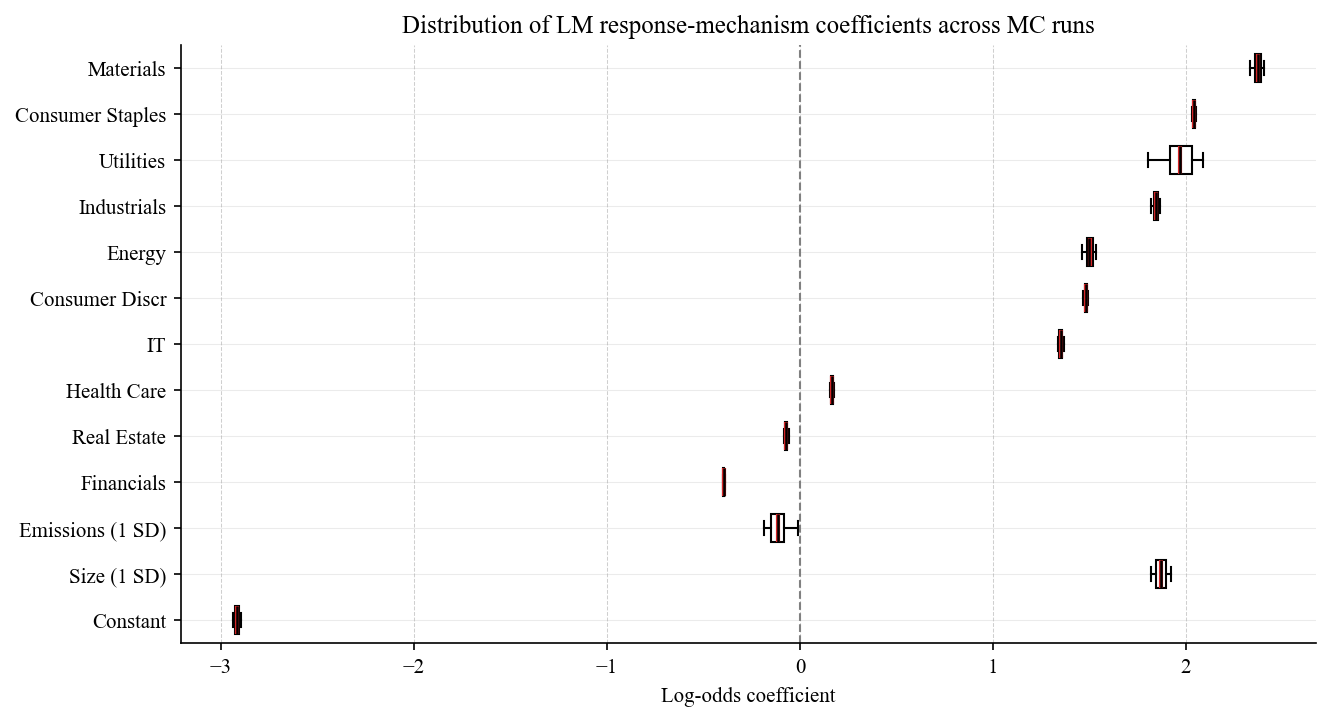

In [ ]:
from corporate_omissions.visualization.plot_lm import (
    plot_response_lm_coef_boxplot,
    ResponseBoxplotSpec,
)

ax = plot_response_lm_coef_boxplot(
    mc_results,
    params_col="lm_params", 
    df_ref=df_lm_avg,
    savepath=str(DIR_FIGURES / f"response_box_plot_lm_{TAG}.pdf"),
    show=False,
)
print(f"Saved: response_box_plot_lm_{TAG}.pdf")

In [ ]:
# Scaled regression coefficients across MC draws
df_params = pd.DataFrame(mc_results["lm_params"].to_list())

# gamma is reported as "log-odds per sd of emissions". Two choices matter here.
#
# WHICH sd: the coefficient multiplies sc1_disclosed_complete, so the yardstick is
# that vector's sd -- NOT df["sc1_disclosed"].std(), which is the disclosed-only sd
# and is larger because non-disclosers are systematically smaller emitters. Using
# the disclosed-only sd inflates every reported gamma.
#
# FIXED vs PER-DRAW: use the mean sd across draws and treat it as a constant.
# Scaling draw-by-draw would fold the yardstick's own noise into gamma's spread --
# sd_y swings ~2x across draws because emissions are heavy-tailed in levels -- which
# inflates the reported dispersion without saying anything about selection. Whether
# gamma != 0 is a claim about the raw per-tonne coefficient; a constant rescale
# preserves its t-statistic, a per-draw rescale does not.
SD_Y = mc_results["sd_y_draw"].mean()
print(f"sigma-bar: mean sd(sc1_disclosed_complete) across draws = {SD_Y:,.0f}")
print(f"           (disclosed-only sd, for reference           = {df['sc1_disclosed'].std():,.0f})")
print(f"           spread across draws: sd of sd_y             = {mc_results['sd_y_draw'].std():,.0f}\n")

df_params["sc1_disclosed_complete"] *= SD_Y
df_params["at"] *= df["at"].std()   # assets fully observed -> one sd is fine

df_params = pd.DataFrame([df_params.mean(), df_params.std()])
df_params.index = ["Mean", "Std. Dev."]
df_params = df_params.round(4)

print("=== Regression Coefficients (Scaled) ===")
print(df_params.to_string())

=== Regression Coefficients (Scaled) ===
            const      at  sc1_disclosed_complete  gsector_Consumer Discr  gsector_Consumer Staples  gsector_Energy  gsector_Financials  gsector_Health Care  gsector_IT  gsector_Industrials  gsector_Materials  gsector_Real Estate  gsector_Utilities  year_2013  year_2014  year_2015  year_2016  year_2017  year_2018  year_2019  year_2020  year_2021  year_2022  year_2023
Mean      -2.9159  1.8713                 -0.1853                  1.4809                    2.0420          1.5000             -0.3938               0.1661      1.3508               1.8443             2.3722              -0.0700             1.9703     0.0897     0.0618     0.1035     0.3241     0.4612     0.6255     0.8758     1.1887     1.4503     1.8248     1.6375
Std. Dev.  0.0118  0.0286                  0.1080                  0.0072                    0.0068          0.0193              0.0029               0.0062      0.0081               0.0119             0.0195           

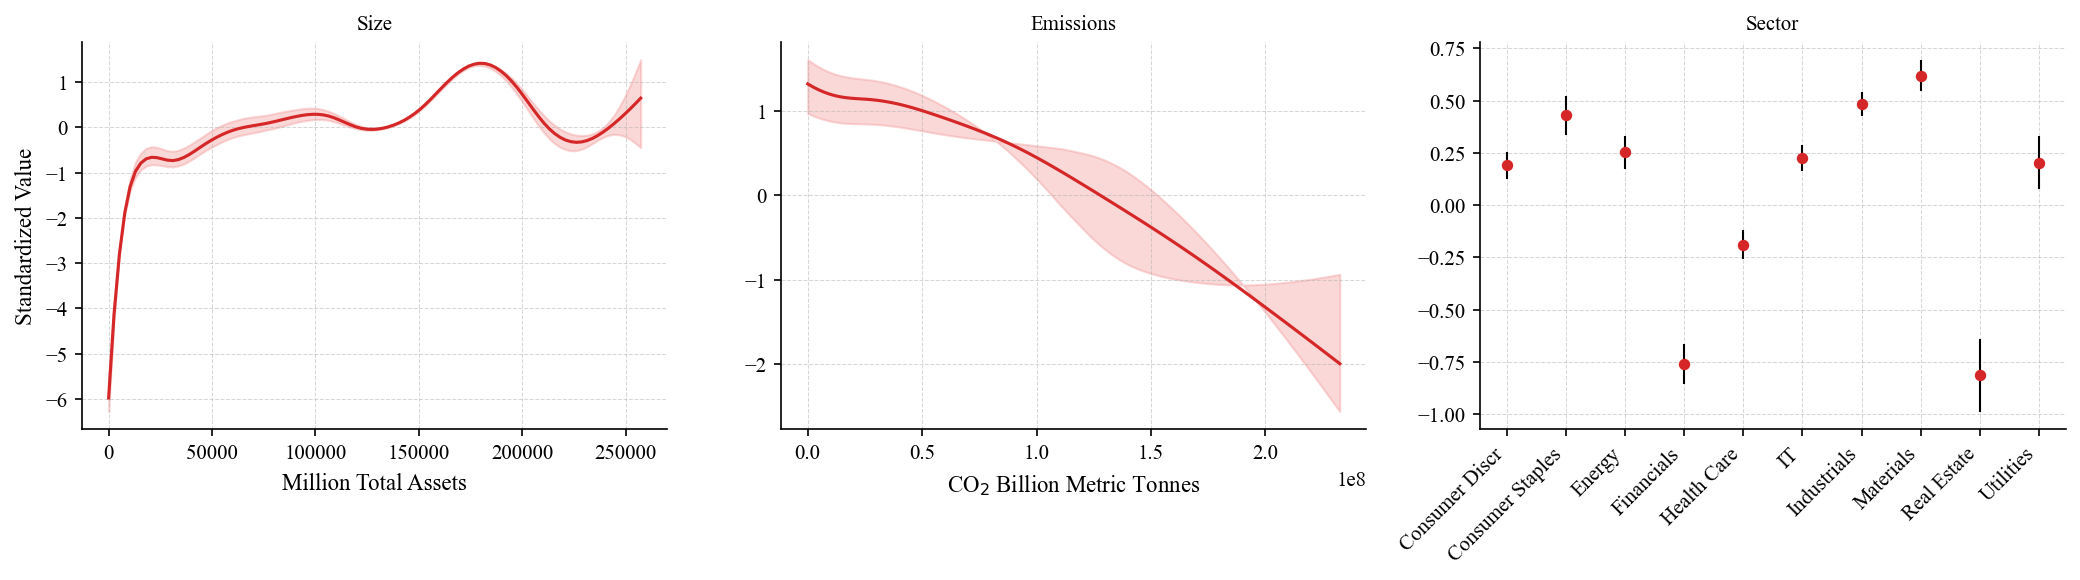

Saved: response_box_plot_gam_baseline_wti_gind_500mc.pdf


In [ ]:
if RUN_GAM:
    from corporate_omissions.visualization.plot_gam import (
        GAMMCSpec, process_gam_pdep_mc, plot_gam_response_mc_3panel
    )

    # Sector labels adapt to the sector column used
    if SPEC["sector_col"] == "gsector":
        sector_term_indices = list(range(3, 13))
        sector_labels = [
            "Consumer Discr", "Consumer Staples", "Energy", "Financials",
            "Health Care", "IT", "Industrials", "Materials",
            "Real Estate", "Utilities",
        ]
    else:
        # gind: more industries — indices depend on the fitted GAM
        n_sectors = df_full[SPEC["sector_col"]].nunique() - 1  # minus baseline
        sector_term_indices = list(range(3, 3 + n_sectors))
        sector_labels = None  # use default numeric labels

    spec = GAMMCSpec(
        size_term=0,
        emis_term=1,
        sector_term_indices=sector_term_indices,
        sector_labels=sector_labels,
        standardize_continuous=True,
    )

    processed = process_gam_pdep_mc(mc_results, spec=spec)

    fig, axs = plot_gam_response_mc_3panel(
        processed,
        savepath=DIR_FIGURES / f"response_box_plot_gam_{TAG}.pdf",
    )
    print(f"Saved: response_box_plot_gam_{TAG}.pdf")
else:
    print("GAM disabled — skipping GAM response plot.")

## Save results

In [ ]:
df_lm_avg.to_parquet(DIR_PROC / f"df_lm_avg_{TAG}.parquet", index=False)
print(f"Saved: df_lm_avg_{TAG}.parquet")

if RUN_GAM and df_gam_avg is not None:
    df_gam_avg.to_parquet(DIR_PROC / f"df_gam_avg_{TAG}.parquet", index=False)
    print(f"Saved: df_gam_avg_{TAG}.parquet")

Saved: df_lm_avg_baseline_wti_gind_500mc.parquet
Saved: df_gam_avg_baseline_wti_gind_500mc.parquet


In [ ]:
cols = ["mean_complete", "mean_adj_lm"]
labels = ["Baseline", "LM"]

if RUN_GAM:
    cols.append("mean_adj_gam")
    labels.append("GAM")

means = pd.DataFrame([mc_results[c] for c in cols]).T
means.columns = labels
means["change_lm"] = (means["LM"] - means["Baseline"]) / means["Baseline"] * 100

print(f"Average change in emissions (LM):  {means['change_lm'].mean():.2f}%")

if RUN_GAM:
    means["change_gam"] = (means["GAM"] - means["Baseline"]) / means["Baseline"] * 100
    print(f"Average change in emissions (GAM): {means['change_gam'].mean():.2f}%")

summary_data = {
    "Baseline Mean":            [means["Baseline"].mean()],
    "Adjusted Mean (LM)":       [means["LM"].mean()],
    "Baseline Std. Dev.":       [means["Baseline"].std()],
    "Adjusted Std. Dev. (LM)":  [means["LM"].std()],
}
if RUN_GAM:
    summary_data["Adjusted Mean (GAM)"]     = [means["GAM"].mean()]
    summary_data["Adjusted Std. Dev. (GAM)"] = [means["GAM"].std()]

summary = pd.DataFrame(summary_data).round(4)

print(f"\n=== Summary ({TAG}) ===")
print(summary.to_string(index=False))

summary_path = DIR_TABLES / f"mc_summary_{TAG}.tex"
write_text(
    summary_path,
    summary.to_latex(index=False, escape=False, float_format="%.4f"),
)
print(f"Saved: {summary_path}")

Average change in emissions (LM):  12.29%
Average change in emissions (GAM): 19.42%

=== Summary (baseline_wti_gind_500mc) ===
 Baseline Mean  Adjusted Mean (LM)  Baseline Std. Dev.  Adjusted Std. Dev. (LM)  Adjusted Mean (GAM)  Adjusted Std. Dev. (GAM)
   962999.9333        1082212.3075          57162.9675               92729.0997         1149188.5869                73625.8488
Saved: ../data/outputs/tables/mc_summary_baseline_wti_gind_500mc.tex
